# 13 — Thesis Figures

**Goal:** Produce all publication-quality figures for the thesis in one place, with
consistent styling (fonts, sizing, palette, DPI). Reads from the analytical panels
and saved result series; does not recompute regressions where avoidable.

**Inputs:**
- `data/panel_monthly.parquet`, `data/panel_yearly.parquet`
- `data/long_short_returns.parquet`, `data/factors.parquet`

**Outputs (all to `output/figures/`, 300 DPI):**
- `fig1_long_short_by_year.png` — annual long-short return
- `fig2_regime_alpha.png` — pre/post-2020 alpha comparison
- `fig3_quintile_returns.png` — mean return by sentiment quintile
- `fig4_subratings.png` — H2b coefficient by sentiment sub-dimension
- `fig5_cumulative_ls.png` — cumulative growth of $1 in the long-short

**Style:** Color palette chosen to remain distinguishable in grayscale. Serif fonts
to match thesis body text. Figure widths sized for a single-column A4 page.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
from scipy.stats import mstats

DATA = Path.home() / "thesis" / "data"
FIGDIR = Path.home() / "thesis" / "output" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

# --- Consistent thesis style ---
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,          # screen preview; saved files use savefig dpi
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Palette: distinguishable in grayscale (varies lightness, not just hue)
C_POS = "#2c5f8a"   # dark blue  — positive / primary
C_NEG = "#c44e52"   # muted red  — negative
C_NEUTRAL = "#7f7f7f"  # gray    — neutral/reference
C_ACCENT = "#4c4c4c"   # near-black — emphasis

FIGW = 6.5   # inches, fits A4 single column with margins

print("Style set. Figures will save to:", FIGDIR)

# --- NaN-safe winsorization fix (2026-06-19): mstats.winsorize silently clips
# missing values to the cap, fabricating firm-years. Preserve NaN instead so the
# regression's dropna handles them. ---
import pandas as _pd
_orig_winsorize = mstats.winsorize
def _winsorize_nan_safe(a, *args, **kwargs):
    s = _pd.Series(a).astype(float); out = s.copy(); m = s.notna()
    out[m] = _orig_winsorize(s[m].to_numpy(), *args, **kwargs)
    return out.to_numpy()
mstats.winsorize = _winsorize_nan_safe


Style set. Figures will save to: /Users/<wrds-username>/thesis/output/figures


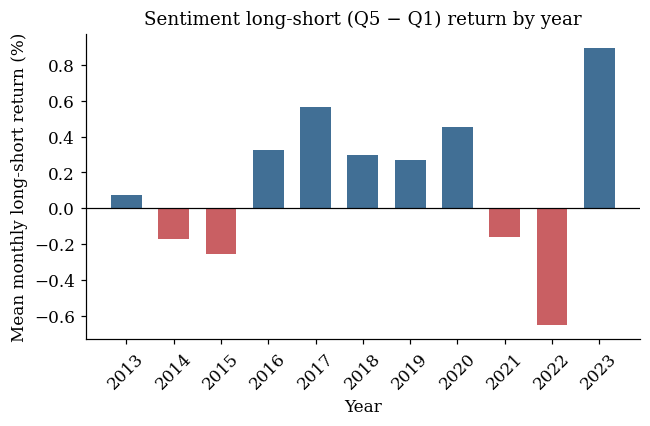

Saved fig1.


In [2]:
panel = pd.read_parquet(DATA / "panel_monthly.parquet"); panel = panel[(panel["year"]>=2013)&(panel["year"]<=2023)].copy()  # restrict to thesis window 2013-2023

# Rebuild quintiles and the per-year long-short (same logic as notebook 09)
fy_sent = panel.groupby(["gvkey", "year"])["sentiment_overall_lag"].first().reset_index()
fy_sent["quintile"] = fy_sent.groupby("year")["sentiment_overall_lag"].transform(
    lambda x: pd.qcut(x, 5, labels=[1,2,3,4,5])
)
pq = panel.merge(fy_sent[["gvkey","year","quintile"]], on=["gvkey","year"])
port = pq.groupby(["year","month","quintile"], observed=True)["ret"].mean().reset_index()
yearly = port.pivot_table(index="year", columns="quintile", values="ret", aggfunc="mean", observed=True)
yearly.columns = [f"Q{int(c)}" for c in yearly.columns]
yearly["LS"] = (yearly["Q5"] - yearly["Q1"]) * 100  # percent

fig, ax = plt.subplots(figsize=(FIGW, 3.6))
colors = [C_POS if v > 0 else C_NEG for v in yearly["LS"]]
ax.bar(yearly.index, yearly["LS"], color=colors, alpha=0.9, width=0.65)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Mean monthly long-short return (%)")
ax.set_title("Sentiment long-short (Q5 − Q1) return by year")
ax.set_xticks(yearly.index)
ax.set_xticklabels(yearly.index, rotation=45)
plt.savefig(FIGDIR / "fig1_long_short_by_year.png")
plt.show()
print("Saved fig1.")

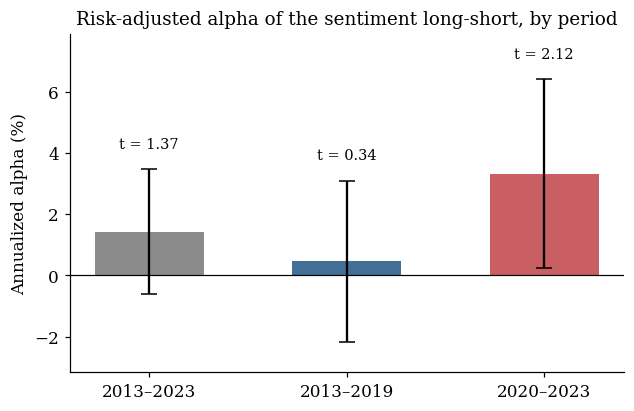

Saved fig2.


In [3]:
# Recompute the alpha for full / pre / post periods (same as notebook 12)
ls = pd.read_parquet(DATA / "long_short_returns.parquet")
ls["date"] = pd.to_datetime(ls["date"]); ls = ls[(ls["date"].dt.year>=2013)&(ls["date"].dt.year<=2023)].copy()  # restrict to thesis window 2013-2023
factors = pd.read_parquet(DATA / "factors.parquet")
reg = ls.merge(factors[["date","mkt_rf","smb","hml","rmw","cma","mom"]], on="date", how="inner")

def get_alpha(data, start, end):
    d = data[(data["date"].dt.year >= start) & (data["date"].dt.year <= end)]
    y = d["long_short"].astype("float64")
    X = sm.add_constant(d[["mkt_rf","smb","hml","rmw","cma","mom"]].astype("float64"))
    res = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 3})
    a = res.params["const"] * 12 * 100      # annualized %
    se = res.bse["const"] * 12 * 100         # annualized SE for error bar
    t = res.tvalues["const"]
    return a, se, t

periods = [("2013–2023", 2013, 2023), ("2013–2019", 2013, 2019), ("2020–2023", 2020, 2023)]
vals = [(lbl,) + get_alpha(reg, s, e) for lbl, s, e in periods]
labels = [v[0] for v in vals]
alphas = [v[1] for v in vals]
ses    = [v[2] for v in vals]
tstats = [v[3] for v in vals]

fig, ax = plt.subplots(figsize=(FIGW, 4.0))
colors = [C_NEUTRAL, C_POS, C_NEG]
# 2026-07-14: error bars switched from +/-1 SE to 95% CI (1.96 x SE),
# closing the open fig2 decision and matching the CI-centric 4.3 prose.
ci = [1.96 * s for s in ses]
bars = ax.bar(labels, alphas, yerr=ci, capsize=5, color=colors, alpha=0.9, width=0.55)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Annualized alpha (%)")
ax.set_title("Risk-adjusted alpha of the sentiment long-short, by period")

# Place each t-label above the TOP of that bar's error bar (whisker), not near the bar top.
# For positive bars the whisker top is alpha+se; for negative bars the whisker bottom
# is alpha-se, so we still label above the bar in that case.
gap = 0.6  # vertical gap in data units (percent)
for bar, a, se, t in zip(bars, alphas, ses, tstats):
    whisker_top = a + 1.96 * se
    label_y = whisker_top + gap
    ax.text(bar.get_x() + bar.get_width()/2, label_y, f"t = {t:.2f}",
            ha="center", va="bottom", fontsize=9.5)

# Expand y-limits so labels above the whiskers aren't clipped
top = max(a + 1.96 * se for a, se in zip(alphas, ses)) + 1.5
bottom = min(min(a - 1.96 * se for a, se in zip(alphas, ses)), 0) - 1.0
ax.set_ylim(bottom, top)

plt.savefig(FIGDIR / "fig2_regime_alpha.png")
plt.show()
print("Saved fig2.")

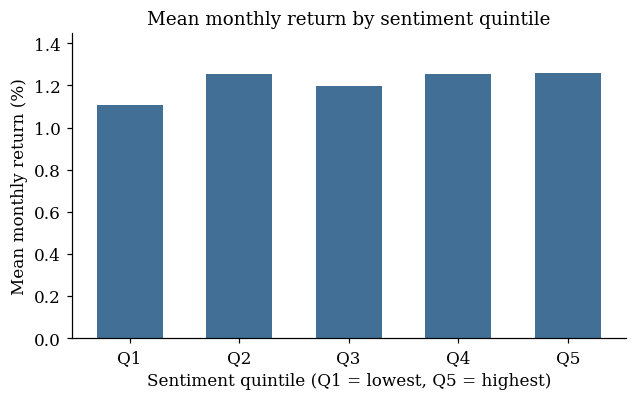

Saved fig3.


In [4]:
# Mean monthly return by quintile (the flat H1 result)
q_means = port.groupby("quintile", observed=True)["ret"].mean() * 100

fig, ax = plt.subplots(figsize=(FIGW, 3.6))
ax.bar([f"Q{i}" for i in q_means.index], q_means.values,
       color=C_POS, alpha=0.9, width=0.6)
ax.set_xlabel("Sentiment quintile (Q1 = lowest, Q5 = highest)")
ax.set_ylabel("Mean monthly return (%)")
ax.set_title("Mean monthly return by sentiment quintile")
# Honest framing: set y-axis from 0 so the flatness is visible, not exaggerated
ax.set_ylim(0, max(q_means.values) * 1.15)
plt.savefig(FIGDIR / "fig3_quintile_returns.png")
plt.show()
print("Saved fig3.")

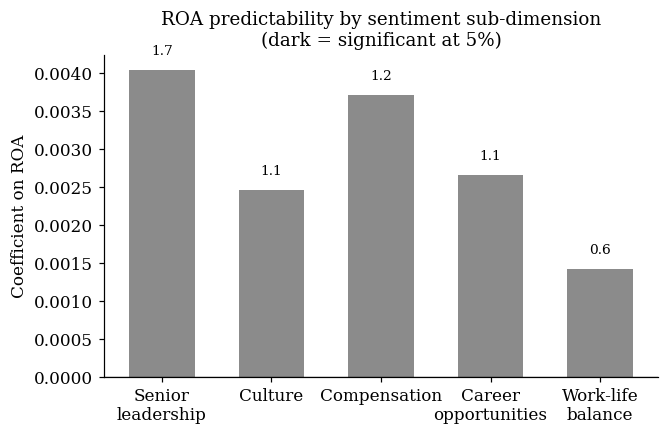

Saved fig4.


In [5]:
# Recompute H2b sub-rating coefficients (full sample, same as notebook 12)
py = pd.read_parquet(DATA / "panel_yearly.parquet")  # winsorize on the FULL panel first (caps match notebooks 11-12)
for v in ["roa","sales_growth"]:
    py[f"{v}_w"] = mstats.winsorize(py[v].astype(float), limits=[0.01,0.01])
py["leverage_w"] = mstats.winsorize(py["leverage"].astype(float), limits=[0.01,0.01])
py = py[(py["fyear"]>=2013)&(py["fyear"]<=2023)].copy()  # restrict AFTER winsorizing, matching notebooks 11-12

subratings = {
    "sentiment_leadership_lag": "Senior\nleadership",
    "sentiment_culture_lag": "Culture",
    "sentiment_comp_lag": "Compensation",
    "sentiment_career_lag": "Career\nopportunities",
    "sentiment_wlb_lag": "Work-life\nbalance",
}

def h2b_coef(data, outcome, var):
    d = data.set_index(["gvkey","fyear"]).dropna(subset=[outcome, var, "log_at", "leverage_w"])
    f = f"{outcome} ~ {var} + log_at + leverage_w + EntityEffects + TimeEffects"
    res = PanelOLS.from_formula(f, data=d, drop_absorbed=True).fit(cov_type="clustered", cluster_entity=True)
    return res.params[var], res.tstats[var]

# Collect coefficients + t-stats for ROA
rows = []
for var, label in subratings.items():
    coef, t = h2b_coef(py, "roa_w", var)
    rows.append({"dim": label, "coef": coef, "t": t})
sub_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(FIGW, 3.8))
# Color by significance: dark if |t|>1.96, gray if not
colors = [C_POS if abs(t) > 1.96 else C_NEUTRAL for t in sub_df["t"]]
bars = ax.bar(sub_df["dim"], sub_df["coef"], color=colors, alpha=0.9, width=0.6)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Coefficient on ROA")
ax.set_title("ROA predictability by sentiment sub-dimension\n(dark = significant at 5%)")
for bar, t in zip(bars, sub_df["t"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0002, f"{t:.1f}",
            ha="center", fontsize=9)
plt.savefig(FIGDIR / "fig4_subratings.png")
plt.show()
print("Saved fig4.")

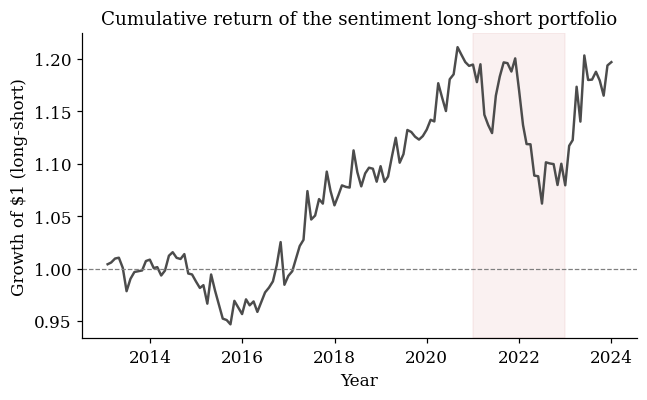

Saved fig5.


In [6]:
# Cumulative growth of $1 invested in the long-short, starting Jan 2013
ls_sorted = ls.sort_values("date").copy()
ls_sorted["cumulative"] = (1 + ls_sorted["long_short"]).cumprod()

fig, ax = plt.subplots(figsize=(FIGW, 3.6))
ax.plot(ls_sorted["date"], ls_sorted["cumulative"], color=C_ACCENT, linewidth=1.6)
ax.axhline(1.0, color=C_NEUTRAL, linewidth=0.8, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel("Growth of $1 (long-short)")
ax.set_title("Cumulative return of the sentiment long-short portfolio")
# Shade the 2021-22 reversal period for honest context
ax.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2022-12-31"),
           color=C_NEG, alpha=0.08)
plt.savefig(FIGDIR / "fig5_cumulative_ls.png")
plt.show()
print("Saved fig5.")

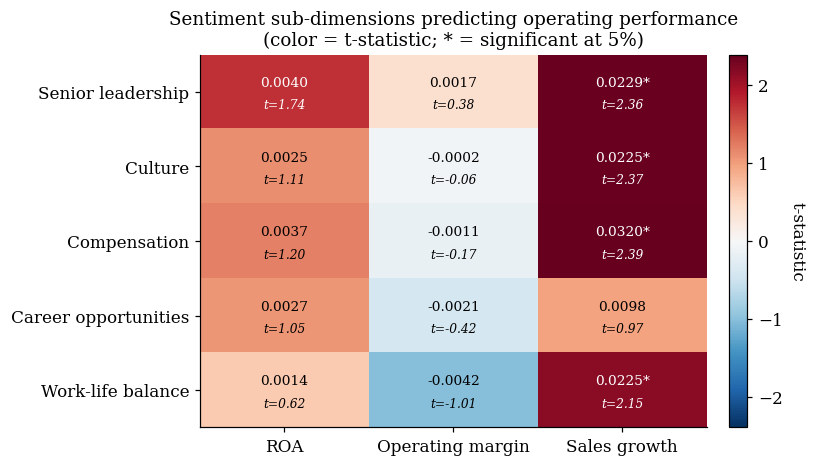

Saved fig6.


In [7]:
import numpy as np

# Reuse the winsorised yearly panel from Cell 6 (py). If not in memory, reload:
py = pd.read_parquet(DATA / "panel_yearly.parquet")  # winsorize on the FULL panel first (caps match notebooks 11-12)
for v in ["roa", "operating_margin", "sales_growth"]:
    py[f"{v}_w"] = mstats.winsorize(py[v].astype(float), limits=[0.01, 0.01])
py["leverage_w"] = mstats.winsorize(py["leverage"].astype(float), limits=[0.01, 0.01])
py = py[(py["fyear"]>=2013)&(py["fyear"]<=2023)].copy()  # restrict AFTER winsorizing, matching notebooks 11-12

subratings = {
    "sentiment_leadership_lag": "Senior leadership",
    "sentiment_culture_lag": "Culture",
    "sentiment_comp_lag": "Compensation",
    "sentiment_career_lag": "Career opportunities",
    "sentiment_wlb_lag": "Work-life balance",
}
outcomes = {
    "roa_w": "ROA",
    "operating_margin_w": "Operating margin",
    "sales_growth_w": "Sales growth",
}

def h2b_full(data, outcome, var):
    d = data.set_index(["gvkey", "fyear"]).dropna(subset=[outcome, var, "log_at", "leverage_w"])
    f = f"{outcome} ~ {var} + log_at + leverage_w + EntityEffects + TimeEffects"
    res = PanelOLS.from_formula(f, data=d, drop_absorbed=True).fit(
        cov_type="clustered", cluster_entity=True
    )
    return res.params[var], res.tstats[var]

# Build matrices: rows = sub-ratings, cols = outcomes
coef_mat = np.zeros((len(subratings), len(outcomes)))
t_mat = np.zeros((len(subratings), len(outcomes)))

for i, var in enumerate(subratings):
    for j, outcome in enumerate(outcomes):
        coef, t = h2b_full(py, outcome, var)
        coef_mat[i, j] = coef
        t_mat[i, j] = t

# --- Plot ---
fig, ax = plt.subplots(figsize=(FIGW, 4.4))

# Diverging colormap centered at zero, scaled by t-stat.
# Symmetric limits so zero maps to white.
tmax = np.abs(t_mat).max()
im = ax.imshow(t_mat, cmap="RdBu_r", vmin=-tmax, vmax=tmax, aspect="auto")

# Ticks
ax.set_xticks(range(len(outcomes)))
ax.set_xticklabels(outcomes.values())
ax.set_yticks(range(len(subratings)))
ax.set_yticklabels(subratings.values())

# Annotate each cell: coefficient on top, t-stat below.
# White text on dark cells, black on light.
for i in range(len(subratings)):
    for j in range(len(outcomes)):
        t = t_mat[i, j]
        c = coef_mat[i, j]
        textcolor = "white" if abs(t) > tmax * 0.55 else "black"
        star = "*" if abs(t) > 1.96 else ""
        ax.text(j, i - 0.12, f"{c:.4f}{star}", ha="center", va="center",
                color=textcolor, fontsize=9)
        ax.text(j, i + 0.18, f"t={t:.2f}", ha="center", va="center",
                color=textcolor, fontsize=8, style="italic")

ax.set_title("Sentiment sub-dimensions predicting operating performance\n"
             "(color = t-statistic; * = significant at 5%)")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("t-statistic", rotation=270, labelpad=15)

plt.savefig(FIGDIR / "fig6_subrating_heatmap.png")
plt.show()
print("Saved fig6.")

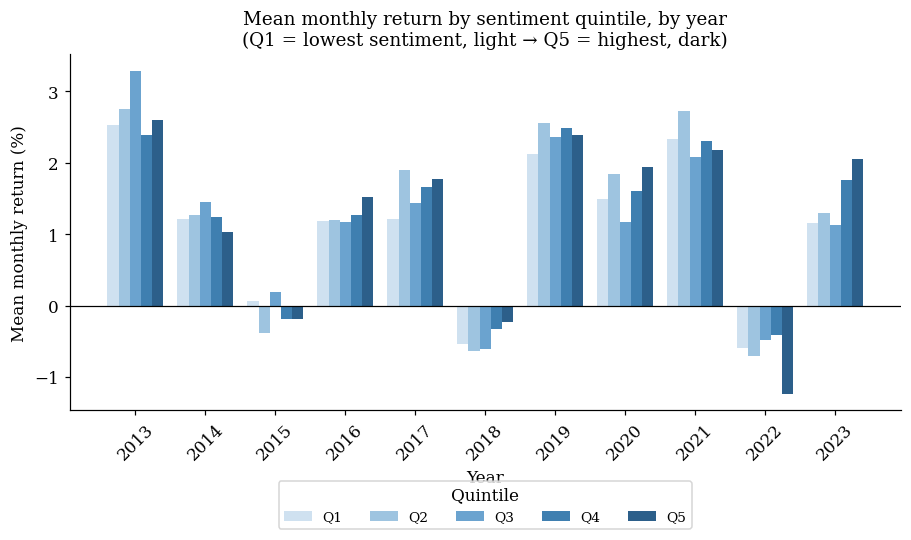

Saved fig7.


In [8]:
# Rebuild the per-year, per-quintile mean monthly returns
# (reuses `port` from Cell 3 if in memory; recompute to be safe)
panel = pd.read_parquet(DATA / "panel_monthly.parquet"); panel = panel[(panel["year"]>=2013)&(panel["year"]<=2023)].copy()  # restrict to thesis window 2013-2023
fy_sent = panel.groupby(["gvkey", "year"])["sentiment_overall_lag"].first().reset_index()
fy_sent["quintile"] = fy_sent.groupby("year")["sentiment_overall_lag"].transform(
    lambda x: pd.qcut(x, 5, labels=[1, 2, 3, 4, 5])
)
pq = panel.merge(fy_sent[["gvkey", "year", "quintile"]], on=["gvkey", "year"])
port = pq.groupby(["year", "month", "quintile"], observed=True)["ret"].mean().reset_index()

# Mean monthly return per (year, quintile), in percent
yq = (port.groupby(["year", "quintile"], observed=True)["ret"].mean() * 100).unstack()
yq.columns = [f"Q{int(c)}" for c in yq.columns]

# --- Plot: grouped bars, 5 quintiles per year ---
years = yq.index.tolist()
n_years = len(years)
n_q = 5
bar_w = 0.16
x = np.arange(n_years)

# Sequential palette: light (Q1) -> dark (Q5), distinguishable in grayscale
q_colors = ["#cfe1f0", "#9ec4e0", "#6ba3cf", "#3f7fb0", "#2c5f8a"]

fig, ax = plt.subplots(figsize=(FIGW * 1.5, 4.2))  # wider — lots of bars
for i in range(n_q):
    ax.bar(x + (i - 2) * bar_w, yq[f"Q{i+1}"], width=bar_w,
           color=q_colors[i], label=f"Q{i+1}")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45)
ax.set_xlabel("Year")
ax.set_ylabel("Mean monthly return (%)")
ax.set_title("Mean monthly return by sentiment quintile, by year\n"
             "(Q1 = lowest sentiment, light → Q5 = highest, dark)")
ax.legend(title="Quintile", ncol=5, fontsize=9, loc="upper center",
          bbox_to_anchor=(0.5, -0.18))

plt.savefig(FIGDIR / "fig7_quintile_by_year.png")
plt.show()
print("Saved fig7.")